# 03 — LSTM Autoencoder

Trains a per-entity **LSTM Autoencoder** on the preprocessed NASA SMAP/MSL windows.

- Encoder compresses each window to a fixed-size latent vector via an LSTM
- Decoder reconstructs the original sequence from the latent vector
- Anomaly score = per-timestep MSE reconstruction error averaged across channels
- Hyperparameters are tuned with **Optuna** on a subset of entities, then the best params are applied to all entities
- Outputs `results/lstm/{entity_id}_{val,test}_scores.npy` ready for threshold-based evaluation

In [114]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import json
import pickle
from pathlib import Path
from tqdm.auto import tqdm
import optuna
import matplotlib.pyplot as plt

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

DATA_DIR = Path("data/processed")
RESULTS_DIR = Path("results/lstm")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

N_EPOCHS = 30
BATCH_SIZE = 256
OPTUNA_TRIALS = 50
OPTUNA_ENTITIES = 10
PRED_STEPS = 5

print(f"Device: {DEVICE}")

Device: mps


In [115]:
with open(DATA_DIR / "metadata.json") as f:
    metadata = json.load(f)

ENTITIES = metadata["entities"]
N_CHANNELS = metadata["n_channels"]
WINDOW_SIZE = metadata["window_size"]
TRAIN_STRIDE = metadata["train_stride"]

print(f"Entities: {len(ENTITIES)}, window_size: {WINDOW_SIZE}, train_stride: {TRAIN_STRIDE}")


class LSTMPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, pred_steps):
        super().__init__()
        self.pred_steps = pred_steps
        self.input_dim = input_dim
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.fc = nn.Linear(hidden_dim, input_dim * pred_steps)

    def forward(self, x):
        # x: (batch, seq_len, input_dim) — first W-PRED_STEPS timesteps
        _, (h_n, _) = self.lstm(x)
        h = h_n[-1]                          # (batch, hidden_dim)
        out = self.fc(h)                      # (batch, input_dim * pred_steps)
        return out.view(-1, self.pred_steps, self.input_dim)  # (batch, pred_steps, input_dim)

Entities: 82, window_size: 100, train_stride: 10


## Training Utilities

In [116]:
def train_model(model, train_loader, val_loader, n_epochs, lr, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []
    pred_steps = model.pred_steps

    for _ in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        for (x,) in train_loader:
            x = x.to(device)
            x_in = x[:, :-pred_steps, :]       # (B, W-K, C)
            x_tgt = x[:, -pred_steps:, :]       # (B, K, C)
            optimizer.zero_grad()
            pred = model(x_in)
            loss = criterion(pred, x_tgt)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * x.size(0)
        train_losses.append(epoch_loss / len(train_loader.dataset))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (x,) in val_loader:
                x = x.to(device)
                x_in = x[:, :-pred_steps, :]
                x_tgt = x[:, -pred_steps:, :]
                pred = model(x_in)
                val_loss += criterion(pred, x_tgt).item() * x.size(0)
        n_val = len(val_loader.dataset)
        val_losses.append(val_loss / n_val if n_val > 0 else float("nan"))

    return model, train_losses, val_losses


def compute_window_scores(model, windows_tensor, device):
    model.eval()
    pred_steps = model.pred_steps
    scores = []
    loader = DataLoader(TensorDataset(windows_tensor), batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            x_in = x[:, :-pred_steps, :]
            x_tgt = x[:, -pred_steps:, :]
            pred = model(x_in)
            # per-channel MSE over pred steps, then max across channels
            mse_per_channel = ((pred - x_tgt) ** 2).mean(dim=1)  # (B, C)
            score = mse_per_channel.max(dim=1).values              # (B,)
            scores.append(score.cpu().numpy())
    return np.concatenate(scores)

## Hyperparameter Tuning with Optuna

In [117]:
def optuna_objective(trial, entity_id, n_channels):
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128, 256])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)

    train_windows = torch.tensor(np.load(DATA_DIR / f"{entity_id}_train.npy"))
    val_windows = torch.tensor(np.load(DATA_DIR / f"{entity_id}_val.npy"))

    train_loader = DataLoader(TensorDataset(train_windows), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(val_windows), batch_size=BATCH_SIZE, shuffle=False)

    model = LSTMPredictor(n_channels, hidden_dim, num_layers, dropout, PRED_STEPS).to(DEVICE)
    _, _, val_losses = train_model(model, train_loader, val_loader, N_EPOCHS, lr, DEVICE)

    last = [v for v in val_losses if not (v != v)]  # filter NaN
    return last[-1] if last else float("inf")

In [118]:
import csv
_labels_map = {}
with open('labeled_anomalies.csv') as _f:
    for _row in csv.DictReader(_f):
        _labels_map[_row['chan_id']] = _row['spacecraft']

smap_pool = [e for e in ENTITIES if _labels_map.get(e) == 'SMAP'][:OPTUNA_ENTITIES]
msl_pool  = [e for e in ENTITIES if _labels_map.get(e) == 'MSL'][:OPTUNA_ENTITIES]
print(f"Optuna: {len(smap_pool)} encji SMAP + {len(msl_pool)} encji MSL")

optuna.logging.set_verbosity(optuna.logging.WARNING)
valid_hidden_dims = [32, 64, 128, 256]

def run_optuna_group(entity_pool, group_name):
    all_params = []
    for entity_id in tqdm(entity_pool, desc=f"Optuna {group_name}"):
        nc = N_CHANNELS[entity_id]
        study = optuna.create_study(direction="minimize")
        study.optimize(
            lambda trial, eid=entity_id, nc=nc: optuna_objective(trial, eid, nc),
            n_trials=OPTUNA_TRIALS,
        )
        all_params.append(study.best_params)
        print(f"  {entity_id}: loss={study.best_value:.6f}, params={study.best_params}")
    avg_hidden = np.mean([p["hidden_dim"] for p in all_params])
    return {
        "hidden_dim": min(valid_hidden_dims, key=lambda v: abs(v - avg_hidden)),
        "num_layers": int(np.round(np.mean([p["num_layers"] for p in all_params]))),
        "lr":         float(np.exp(np.mean([np.log(p["lr"]) for p in all_params]))),
        "dropout":    float(np.mean([p["dropout"] for p in all_params])),
    }

best_params_smap = run_optuna_group(smap_pool, "SMAP")
with open(RESULTS_DIR / "best_params_smap.json", "w") as f:
    json.dump(best_params_smap, f, indent=2)
print(f"\nSMAP: {best_params_smap}")

best_params_msl = run_optuna_group(msl_pool, "MSL")
with open(RESULTS_DIR / "best_params_msl.json", "w") as f:
    json.dump(best_params_msl, f, indent=2)
print(f"MSL:  {best_params_msl}")

Optuna: 10 encji SMAP + 10 encji MSL


Optuna SMAP:   0%|          | 0/10 [00:00<?, ?it/s]

  A-1: loss=1.630402, params={'hidden_dim': 128, 'num_layers': 1, 'lr': 0.002092995198862842, 'dropout': 0.2191079066312573}
  A-2: loss=0.356855, params={'hidden_dim': 64, 'num_layers': 1, 'lr': 0.004537461812720837, 'dropout': 0.21616137230560056}
  A-3: loss=0.378545, params={'hidden_dim': 256, 'num_layers': 1, 'lr': 0.0016984806627901524, 'dropout': 0.06280596657555912}
  A-4: loss=0.997153, params={'hidden_dim': 128, 'num_layers': 1, 'lr': 0.001934702313909532, 'dropout': 0.025661781528510584}
  A-5: loss=0.772890, params={'hidden_dim': 64, 'num_layers': 1, 'lr': 0.0016894733759658738, 'dropout': 0.25373334365480804}
  A-6: loss=19.315805, params={'hidden_dim': 256, 'num_layers': 1, 'lr': 0.004148911755534598, 'dropout': 0.1319457711142072}
  A-7: loss=0.014016, params={'hidden_dim': 256, 'num_layers': 1, 'lr': 0.009989309180493712, 'dropout': 0.19290607095146897}
  A-8: loss=0.000104, params={'hidden_dim': 64, 'num_layers': 1, 'lr': 0.009903646636554568, 'dropout': 0.030555326246

Optuna MSL:   0%|          | 0/10 [00:00<?, ?it/s]

  C-1: loss=0.130126, params={'hidden_dim': 64, 'num_layers': 1, 'lr': 0.004858635325251615, 'dropout': 0.2708115233410645}
  C-2: loss=0.017985, params={'hidden_dim': 128, 'num_layers': 1, 'lr': 0.00021833451326034705, 'dropout': 0.07846966026277755}
  D-14: loss=0.174023, params={'hidden_dim': 256, 'num_layers': 1, 'lr': 0.00019666737839405627, 'dropout': 0.18586621555273203}
  D-15: loss=0.296744, params={'hidden_dim': 256, 'num_layers': 1, 'lr': 0.000472519792767812, 'dropout': 0.2829829770028474}
  D-16: loss=0.040047, params={'hidden_dim': 256, 'num_layers': 2, 'lr': 0.0003802108469591919, 'dropout': 0.21336118894695497}
  F-4: loss=0.100026, params={'hidden_dim': 256, 'num_layers': 2, 'lr': 0.0009692795845296098, 'dropout': 0.26629649118485826}
  F-5: loss=0.204420, params={'hidden_dim': 64, 'num_layers': 2, 'lr': 0.005907118335335542, 'dropout': 0.2549820393860207}
  F-7: loss=0.203474, params={'hidden_dim': 128, 'num_layers': 1, 'lr': 0.009993871463579357, 'dropout': 0.0024376

## Training on All Entities

SMAP params: {'hidden_dim': 128, 'num_layers': 1, 'lr': 0.0037099188468590763, 'dropout': 0.1314622252069261}
MSL  params: {'hidden_dim': 128, 'num_layers': 1, 'lr': 0.0014155076295215643, 'dropout': 0.20780921595909732}


Training all entities:   0%|          | 0/82 [00:00<?, ?it/s]

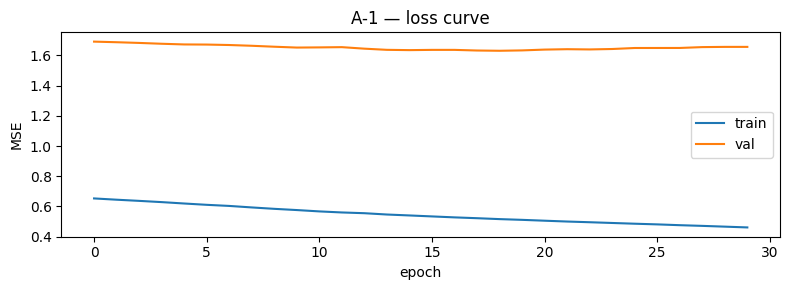

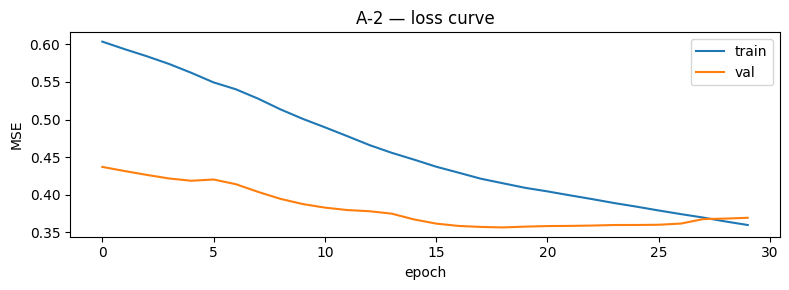

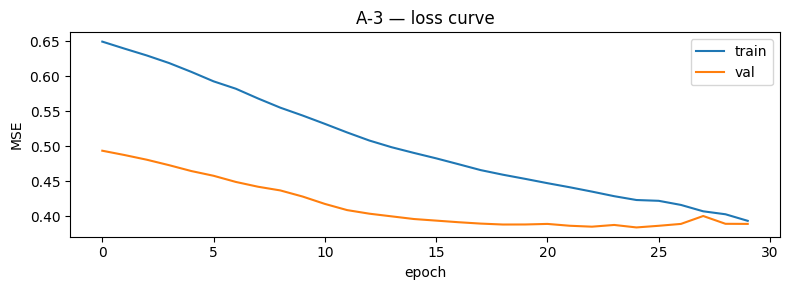

In [119]:
import csv as _csv
_lmap = {}
with open('labeled_anomalies.csv') as _f:
    for _row in _csv.DictReader(_f):
        _lmap[_row['chan_id']] = _row['spacecraft']

with open(RESULTS_DIR / "best_params_smap.json") as f:
    best_params_smap = json.load(f)
with open(RESULTS_DIR / "best_params_msl.json") as f:
    best_params_msl = json.load(f)

print("SMAP params:", best_params_smap)
print("MSL  params:", best_params_msl)

trained_models = {}

for idx, entity_id in enumerate(tqdm(ENTITIES, desc="Training all entities")):
    nc = N_CHANNELS[entity_id]
    train_windows = torch.tensor(np.load(DATA_DIR / f"{entity_id}_train.npy"))
    val_windows = torch.tensor(np.load(DATA_DIR / f"{entity_id}_val.npy"))

    train_loader = DataLoader(TensorDataset(train_windows), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(val_windows), batch_size=BATCH_SIZE, shuffle=False)

    bp = best_params_msl if _lmap.get(entity_id) == 'MSL' else best_params_smap
    model = LSTMPredictor(
        nc,
        bp["hidden_dim"],
        bp["num_layers"],
        bp["dropout"],
        PRED_STEPS,
    ).to(DEVICE)

    model, train_losses, val_losses = train_model(
        model, train_loader, val_loader, N_EPOCHS, bp["lr"], DEVICE
    )

    torch.save(model.state_dict(), RESULTS_DIR / f"{entity_id}_model.pt")
    trained_models[entity_id] = model

    if idx < 3:
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(train_losses, label="train")
        ax.plot(val_losses, label="val")
        ax.set_title(f"{entity_id} — loss curve")
        ax.set_xlabel("epoch")
        ax.set_ylabel("MSE")
        ax.legend()
        plt.tight_layout()
        plt.show()

## Anomaly Score Computation

In [120]:
import csv as _csv
_lmap = {}
with open('labeled_anomalies.csv') as _f:
    for _row in _csv.DictReader(_f):
        _lmap[_row['chan_id']] = _row['spacecraft']

with open(RESULTS_DIR / "best_params_smap.json") as f:
    best_params_smap = json.load(f)
with open(RESULTS_DIR / "best_params_msl.json") as f:
    best_params_msl = json.load(f)

for entity_id in tqdm(ENTITIES, desc="Computing scores"):
    nc = N_CHANNELS[entity_id]

    bp = best_params_msl if _lmap.get(entity_id) == 'MSL' else best_params_smap
    model = LSTMPredictor(nc, bp["hidden_dim"], bp["num_layers"], bp["dropout"], PRED_STEPS).to(DEVICE)
    state = torch.load(RESULTS_DIR / f"{entity_id}_model.pt", map_location=DEVICE)
    model.load_state_dict(state)

    test_windows = torch.tensor(np.load(DATA_DIR / f"{entity_id}_test.npy"))
    test_scores = compute_window_scores(model, test_windows, DEVICE)
    np.save(RESULTS_DIR / f"{entity_id}_test_scores.npy", test_scores)

    val_windows_arr = np.load(DATA_DIR / f"{entity_id}_val.npy")
    if val_windows_arr.ndim < 3 or len(val_windows_arr) == 0:
        np.save(RESULTS_DIR / f"{entity_id}_val_scores.npy", np.array([], dtype=np.float32))
        continue

    val_windows = torch.tensor(val_windows_arr)
    window_scores = compute_window_scores(model, val_windows, DEVICE)

    n_val_raw = (len(val_windows_arr) - 1) * TRAIN_STRIDE + WINDOW_SIZE
    score_sum = np.zeros(n_val_raw, dtype=np.float64)
    count = np.zeros(n_val_raw, dtype=np.int64)
    for i, score in enumerate(window_scores):
        start = i * TRAIN_STRIDE
        end = start + WINDOW_SIZE
        score_sum[start:end] += score
        count[start:end] += 1
    count = np.where(count == 0, 1, count)
    val_scores = (score_sum / count).astype(np.float32)
    np.save(RESULTS_DIR / f"{entity_id}_val_scores.npy", val_scores)

print("Scores saved for all entities.")

Computing scores:   0%|          | 0/82 [00:00<?, ?it/s]

Scores saved for all entities.


## Score Distribution (Sample Entity)

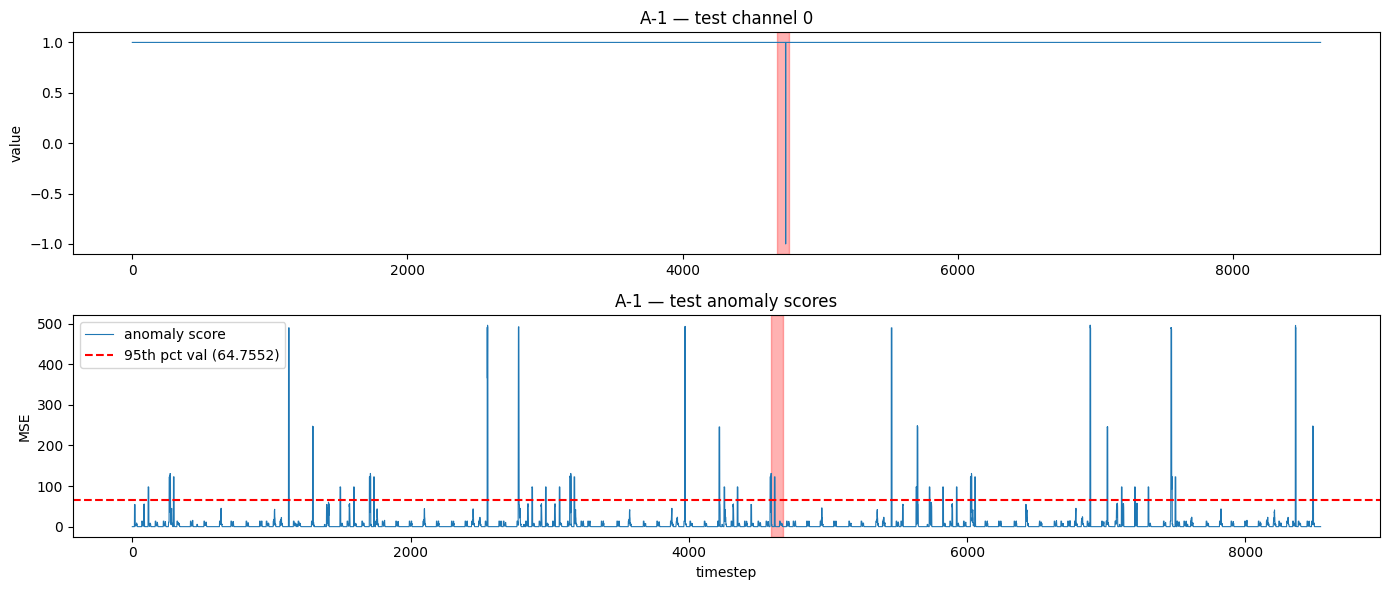

In [121]:
import pandas as pd

sample_id = ENTITIES[0]
test_scores = np.load(RESULTS_DIR / f"{sample_id}_test_scores.npy")
val_scores = np.load(RESULTS_DIR / f"{sample_id}_val_scores.npy")

labels_df = pd.read_csv("labeled_anomalies.csv")
entity_labels = labels_df[labels_df["chan_id"] == sample_id]

test_raw = np.load(DATA_DIR / ".." / ".." / "data" / "test" / f"{sample_id}.npy")
if test_raw.ndim == 1:
    test_raw = test_raw.reshape(-1, 1)

threshold = np.percentile(val_scores, 95)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

ax0 = axes[0]
ax0.plot(test_raw[:, 0], linewidth=0.8)
for _, row in entity_labels.iterrows():
    for seg in json.loads(row["anomaly_sequences"]):
        ax0.axvspan(seg[0], seg[1], alpha=0.3, color="red", label="anomaly")
ax0.set_title(f"{sample_id} — test channel 0")
ax0.set_ylabel("value")

ax1 = axes[1]
ax1.plot(test_scores, linewidth=0.8, label="anomaly score")
ax1.axhline(threshold, color="red", linestyle="--", label=f"95th pct val ({threshold:.4f})")
for _, row in entity_labels.iterrows():
    for seg in json.loads(row["anomaly_sequences"]):
        score_start = max(0, seg[0] - WINDOW_SIZE)
        score_end = max(0, seg[1] - WINDOW_SIZE)
        if score_end > score_start:
            ax1.axvspan(score_start, score_end, alpha=0.3, color="red")
ax1.set_title(f"{sample_id} — test anomaly scores")
ax1.set_ylabel("MSE")
ax1.set_xlabel("timestep")
ax1.legend()

plt.tight_layout()
plt.show()